In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/raw/fake_job_postings.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFraud distribution:")
print(df['fraudulent'].value_counts())
print("\nFraud percentage:", 
      round(df['fraudulent'].mean() * 100, 2), "%")

Shape: (17880, 18)

Columns: ['job_id', 'title', 'location', 'department', 'salary_range', 'company_profile', 'description', 'requirements', 'benefits', 'telecommuting', 'has_company_logo', 'has_questions', 'employment_type', 'required_experience', 'required_education', 'industry', 'function', 'fraudulent']

Fraud distribution:
fraudulent
0    17014
1      866
Name: count, dtype: int64

Fraud percentage: 4.84 %


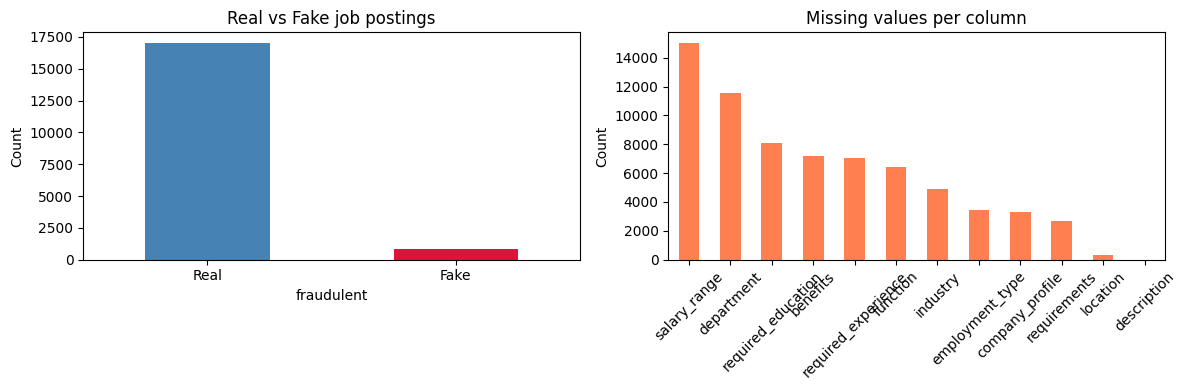

Chart saved!


In [2]:
# Class distribution chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
df['fraudulent'].value_counts().plot(
    kind='bar', ax=axes[0],
    color=['steelblue', 'crimson'],
    edgecolor='none'
)
axes[0].set_title('Real vs Fake job postings')
axes[0].set_xticklabels(['Real', 'Fake'], rotation=0)
axes[0].set_ylabel('Count')

# Missing values heatmap
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0].plot(
    kind='bar', ax=axes[1],
    color='coral', edgecolor='none'
)
axes[1].set_title('Missing values per column')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../data/processed/class_distribution.png', dpi=150)
plt.show()
print("Chart saved!")

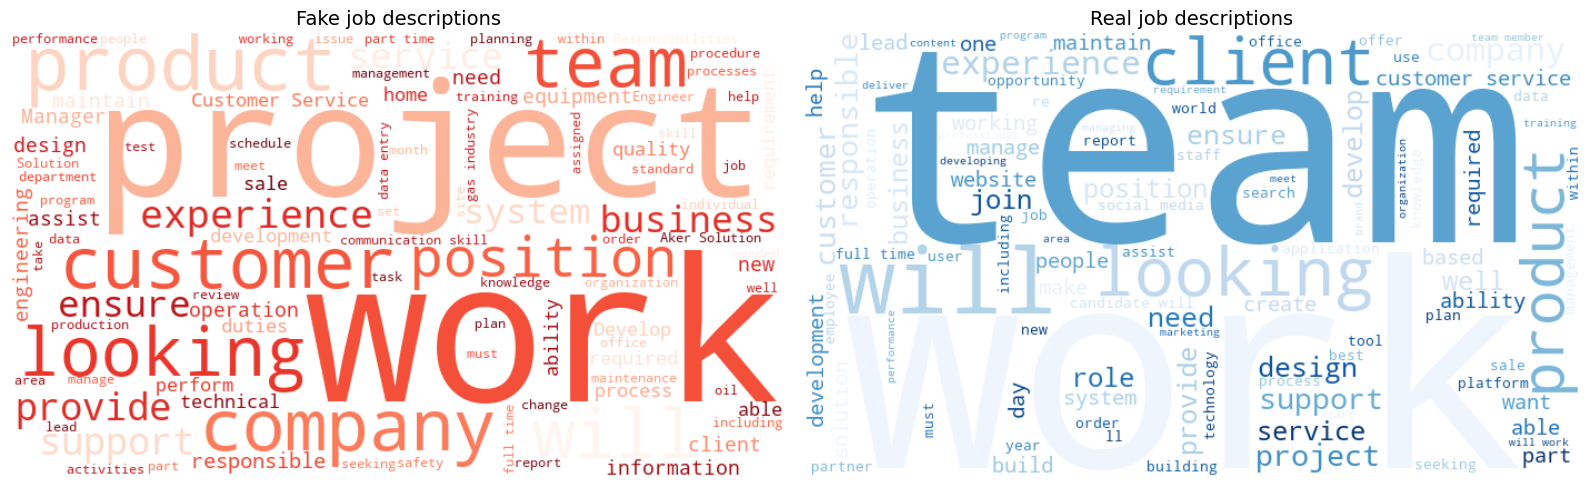

WordClouds saved!


In [3]:
from wordcloud import WordCloud

fake_text = ' '.join(df[df['fraudulent']==1]['description'].dropna())
real_text = ' '.join(df[df['fraudulent']==0]['description'].dropna())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

wc_fake = WordCloud(width=700, height=400,
                    background_color='white',
                    colormap='Reds',
                    max_words=100).generate(fake_text)

wc_real = WordCloud(width=700, height=400,
                    background_color='white',
                    colormap='Blues',
                    max_words=100).generate(real_text)

axes[0].imshow(wc_fake, interpolation='bilinear')
axes[0].set_title('Fake job descriptions', fontsize=14)
axes[0].axis('off')

axes[1].imshow(wc_real, interpolation='bilinear')
axes[1].set_title('Real job descriptions', fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.savefig('../data/processed/wordclouds.png', dpi=150)
plt.show()
print("WordClouds saved!")

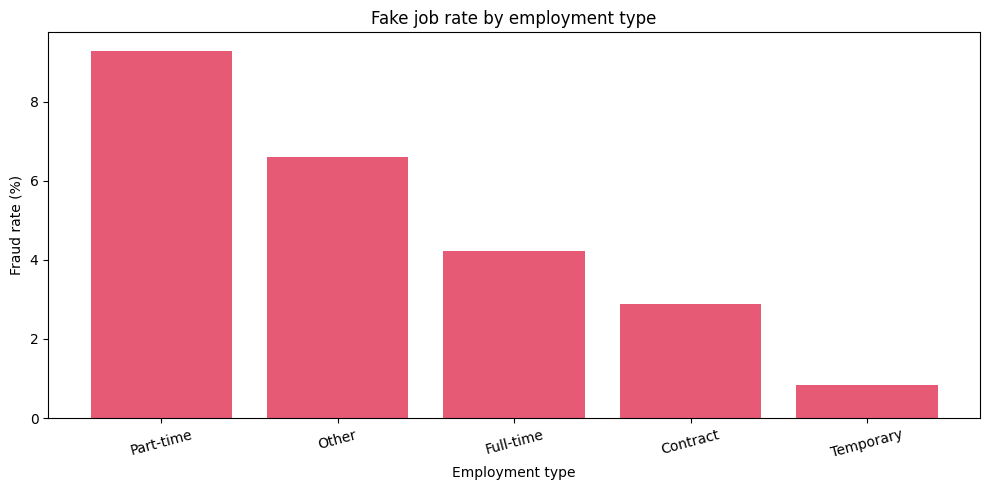

In [4]:
# Fake rate by employment type
emp_fraud = df.groupby('employment_type')['fraudulent'].agg(
    ['mean','count']
).reset_index()
emp_fraud.columns = ['employment_type','fraud_rate','count']
emp_fraud = emp_fraud[emp_fraud['count'] > 50]
emp_fraud = emp_fraud.sort_values('fraud_rate', ascending=False)

plt.figure(figsize=(10,5))
plt.bar(emp_fraud['employment_type'],
        emp_fraud['fraud_rate']*100,
        color='crimson', alpha=0.7)
plt.title('Fake job rate by employment type')
plt.ylabel('Fraud rate (%)')
plt.xlabel('Employment type')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('../data/processed/fraud_by_employment.png', dpi=150)
plt.show()